In [1]:
import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATASET_ROOT = PROJECT_ROOT / "data" / "merged_yolo_grouped"
METADATA_DIR = DATASET_ROOT / "metadata"
EDA_OUTPUT_DIR = PROJECT_ROOT / "output" / "EDA"
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(name: str, fig=None, dpi: int = 300) -> Path:
    if fig is None:
        fig = plt.gcf()
    output_path = EDA_OUTPUT_DIR / f"{name}.png"
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure to {output_path.relative_to(PROJECT_ROOT)}")
    return output_path

image_df = pd.read_csv(METADATA_DIR / "image_metadata.csv")
bbox_df = pd.read_csv(METADATA_DIR / "bbox_metadata.csv")
group_df = pd.read_csv(METADATA_DIR / "group_metadata.csv")
summary = json.loads((METADATA_DIR / "summary.json").read_text())

random.seed(summary["random_seed"])

print(json.dumps(summary, indent=2))

{
  "random_seed": 42,
  "ratios": {
    "train": 0.7,
    "valid": 0.15,
    "test": 0.15
  },
  "annotation_files": [
    "data/Data_side/test/Bright_Field/_annotations.coco.json",
    "data/Data_side/test/Dark_Field/_annotations.coco.json",
    "data/Data_side/train/_annotations.coco.json",
    "data/Data_side/valid/_annotations.coco.json",
    "data/Data_top/train/_annotations.coco.json"
  ],
  "raw_images": 19728,
  "found_images": 11091,
  "missing_files_skipped": 8637,
  "unique_images_after_dedup": 10367,
  "removed_duplicates": 724,
  "unique_groups": 1241,
  "images_without_annotations": 1984,
  "split_counts": [
    {
      "split": "test",
      "image_count": 1562,
      "group_count": 187,
      "positive_images": 1227,
      "negative_images": 335
    },
    {
      "split": "train",
      "image_count": 7202,
      "group_count": 868,
      "positive_images": 5842,
      "negative_images": 1360
    },
    {
      "split": "valid",
      "image_count": 1603,
      "group

In [2]:
image_df.head()

,split,group_key,image_key,dataset,original_split,field,orientation,stem,image_name,source_path,output_image,output_label,width,height,annotation_count,is_positive,class_names
0,valid,S100_Image__2025-09-10__11-46-17_bright_1,side::S100_Image__2025-09-10__11-46-17_bright_...,Data_side,train,Bright_Field,side,S100_Image__2025-09-10__11-46-17_bright_1_crop_9,S100_Image__2025-09-10__11-46-17_bright_1_crop...,data/Data_top/train/Bright_Field/top/S100_Imag...,data/merged_yolo_grouped/images/valid/side__S1...,data/merged_yolo_grouped/labels/valid/side__S1...,448,448,2,True,Tip_Wear
1,train,S100_Image__2025-09-10__11-47-01_dark_1,side::S100_Image__2025-09-10__11-47-01_dark_1_...,Data_side,train,Bright_Field,side,S100_Image__2025-09-10__11-47-01_dark_1_crop_9,S100_Image__2025-09-10__11-47-01_dark_1_crop_9...,data/Data_top/train/Bright_Field/top/S100_Imag...,data/merged_yolo_grouped/images/train/side__S1...,data/merged_yolo_grouped/labels/train/side__S1...,448,448,2,True,Tip_Wear
2,train,S101_Image__2025-09-10__12-16-33_dark_2,side::S101_Image__2025-09-10__12-16-33_dark_2_...,Data_side,train,Dark_Field,side,S101_Image__2025-09-10__12-16-33_dark_2_crop_1,S101_Image__2025-09-10__12-16-33_dark_2_crop_1...,data/Data_side/train/Dark_Field/side/S101_Imag...,data/merged_yolo_grouped/images/train/side__S1...,data/merged_yolo_grouped/labels/train/side__S1...,448,448,2,True,Broken|Chipped
3,train,S101_Image__2025-09-10__12-16-33_dark_2,side::S101_Image__2025-09-10__12-16-33_dark_2_...,Data_side,train,Dark_Field,side,S101_Image__2025-09-10__12-16-33_dark_2_crop_2,S101_Image__2025-09-10__12-16-33_dark_2_crop_2...,data/Data_side/train/Dark_Field/side/S101_Imag...,data/merged_yolo_grouped/images/train/side__S1...,data/merged_yolo_grouped/labels/train/side__S1...,448,448,3,True,Broken|Chipped|Severe_Rust
4,train,S101_Image__2025-09-10__12-16-33_dark_2,side::S101_Image__2025-09-10__12-16-33_dark_2_...,Data_side,train,Dark_Field,side,S101_Image__2025-09-10__12-16-33_dark_2_crop_3,S101_Image__2025-09-10__12-16-33_dark_2_crop_3...,data/Data_side/train/Dark_Field/side/S101_Imag...,data/merged_yolo_grouped/images/train/side__S1...,data/merged_yolo_grouped/labels/train/side__S1...,448,448,2,True,Broken|Severe_Rust


In [3]:
overview = pd.DataFrame(summary["split_counts"])
overview

,split,image_count,group_count,positive_images,negative_images
0,test,1562,187,1227,335
1,train,7202,868,5842,1360
2,valid,1603,186,1314,289


Saved figure to output/EDA/split_overview.png


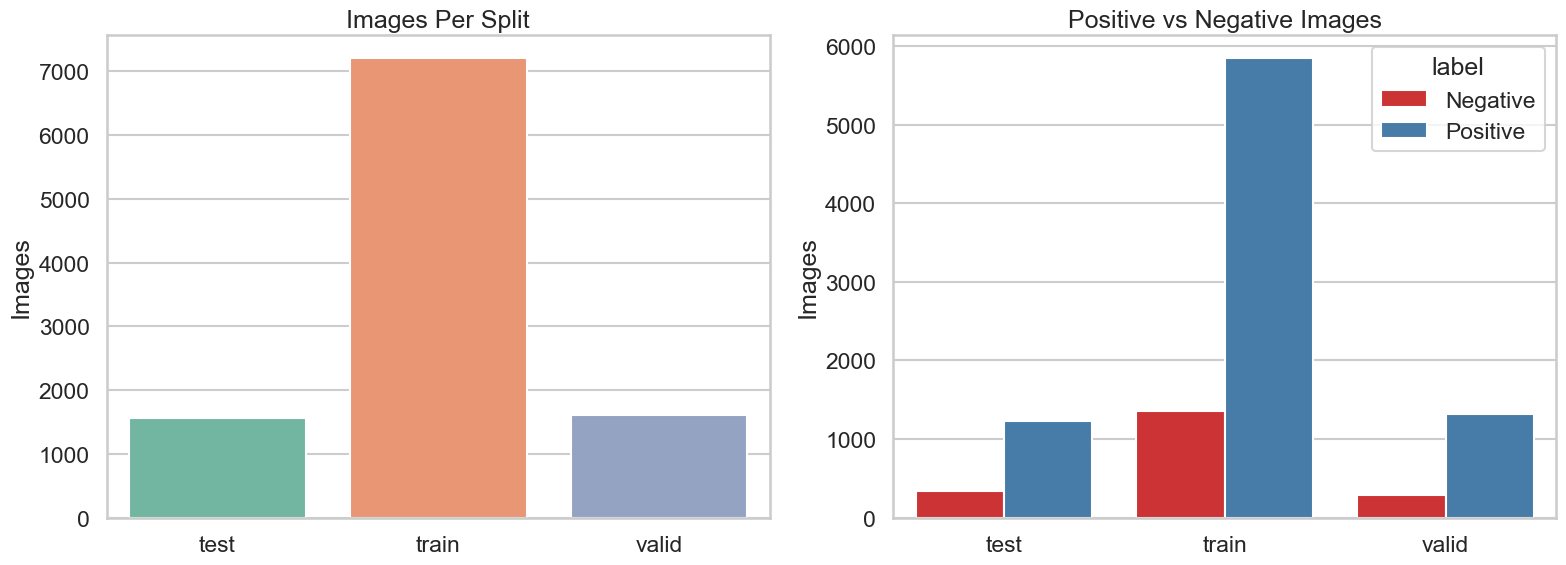

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=overview,
    x="split",
    y="image_count",
    hue="split",
    legend=False,
    ax=axes[0],
    palette="Set2",
)
axes[0].set_title("Images Per Split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Images")

split_mix = (
    image_df.groupby(["split", "is_positive"]).size().rename("count").reset_index()
)
split_mix["label"] = split_mix["is_positive"].map({True: "Positive", False: "Negative"})
sns.barplot(data=split_mix, x="split", y="count", hue="label", ax=axes[1], palette="Set1")
axes[1].set_title("Positive vs Negative Images")
axes[1].set_xlabel("")
axes[1].set_ylabel("Images")

plt.tight_layout()
save_figure("split_overview", fig)
plt.show()

Saved figure to output/EDA/orientation_and_field_distribution.png


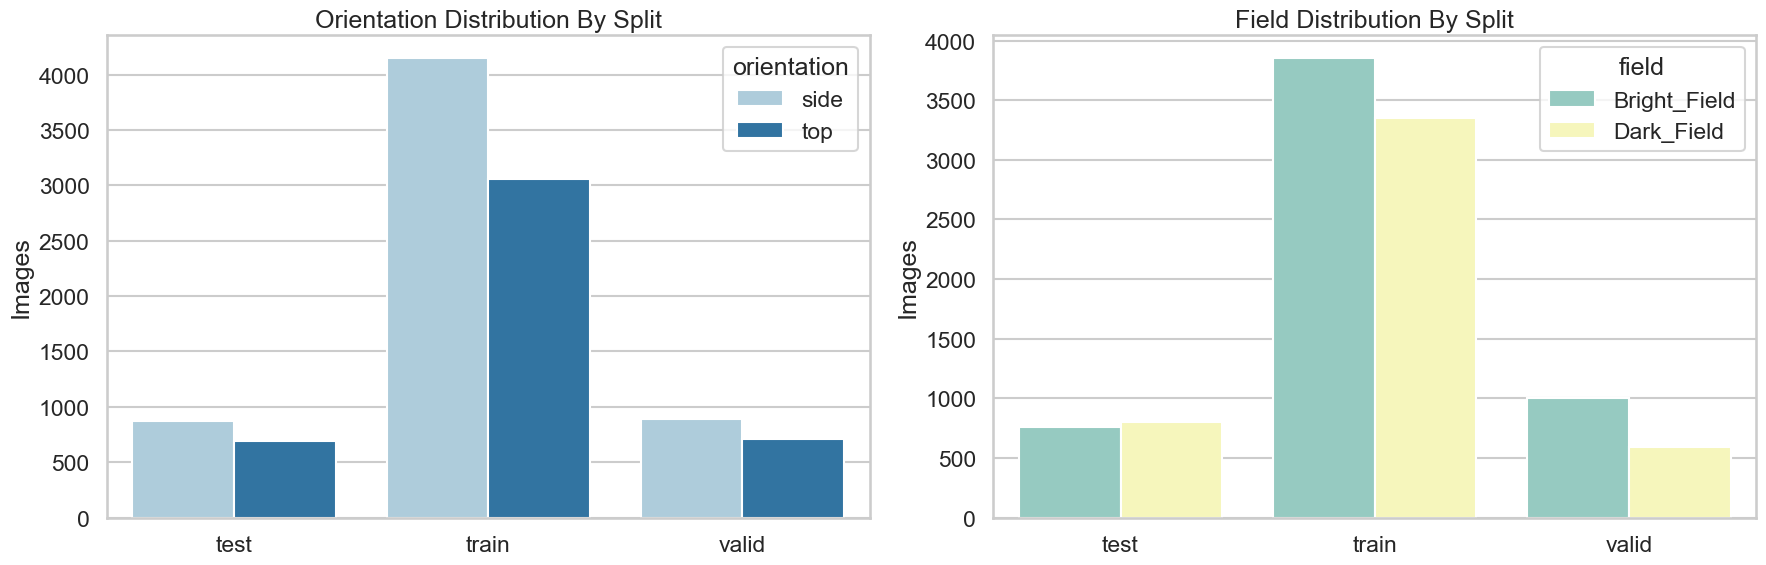

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

orientation_split = image_df.groupby(["split", "orientation"]).size().rename("count").reset_index()
sns.barplot(data=orientation_split, x="split", y="count", hue="orientation", ax=axes[0], palette="Paired")
axes[0].set_title("Orientation Distribution By Split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Images")

field_split = image_df.groupby(["split", "field"]).size().rename("count").reset_index()
sns.barplot(data=field_split, x="split", y="count", hue="field", ax=axes[1], palette="Set3")
axes[1].set_title("Field Distribution By Split")
axes[1].set_xlabel("")
axes[1].set_ylabel("Images")

plt.tight_layout()
save_figure("orientation_and_field_distribution", fig)
plt.show()

Saved figure to output/EDA/class_annotation_and_image_counts.png


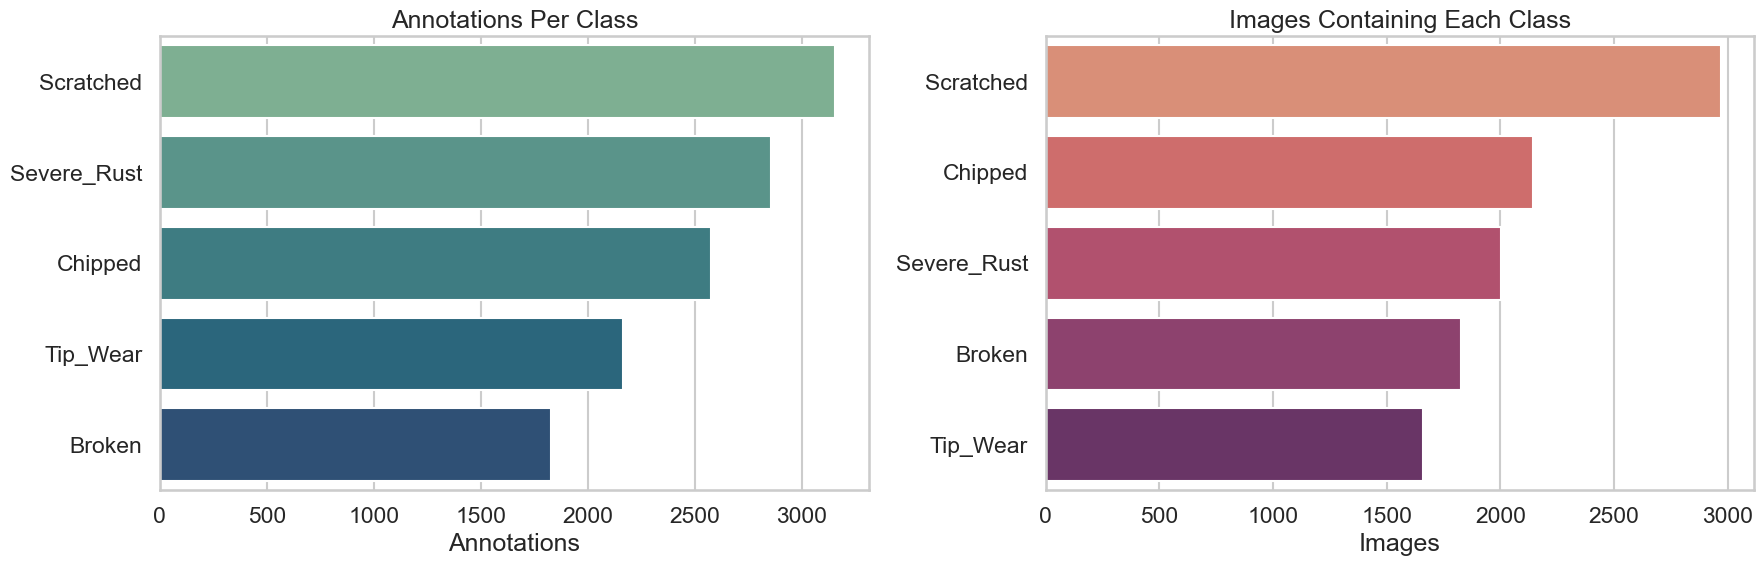

In [6]:
class_counts = (
    bbox_df.groupby("class_name").size().sort_values(ascending=False).rename("annotation_count").reset_index()
)
class_image_counts = (
    image_df.assign(class_name=image_df["class_names"].fillna(""))
    .loc[lambda df: df["class_name"] != ""]
    .assign(class_name=lambda df: df["class_name"].str.split("|"))
    .explode("class_name")
    .groupby("class_name")
    .size()
    .sort_values(ascending=False)
    .rename("image_count")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(
    data=class_counts,
    x="annotation_count",
    y="class_name",
    hue="class_name",
    legend=False,
    ax=axes[0],
    palette="crest",
)
axes[0].set_title("Annotations Per Class")
axes[0].set_xlabel("Annotations")
axes[0].set_ylabel("")

sns.barplot(
    data=class_image_counts,
    x="image_count",
    y="class_name",
    hue="class_name",
    legend=False,
    ax=axes[1],
    palette="flare",
)
axes[1].set_title("Images Containing Each Class")
axes[1].set_xlabel("Images")
axes[1].set_ylabel("")

plt.tight_layout()
save_figure("class_annotation_and_image_counts", fig)
plt.show()

Saved figure to output/EDA/bbox_statistics.png


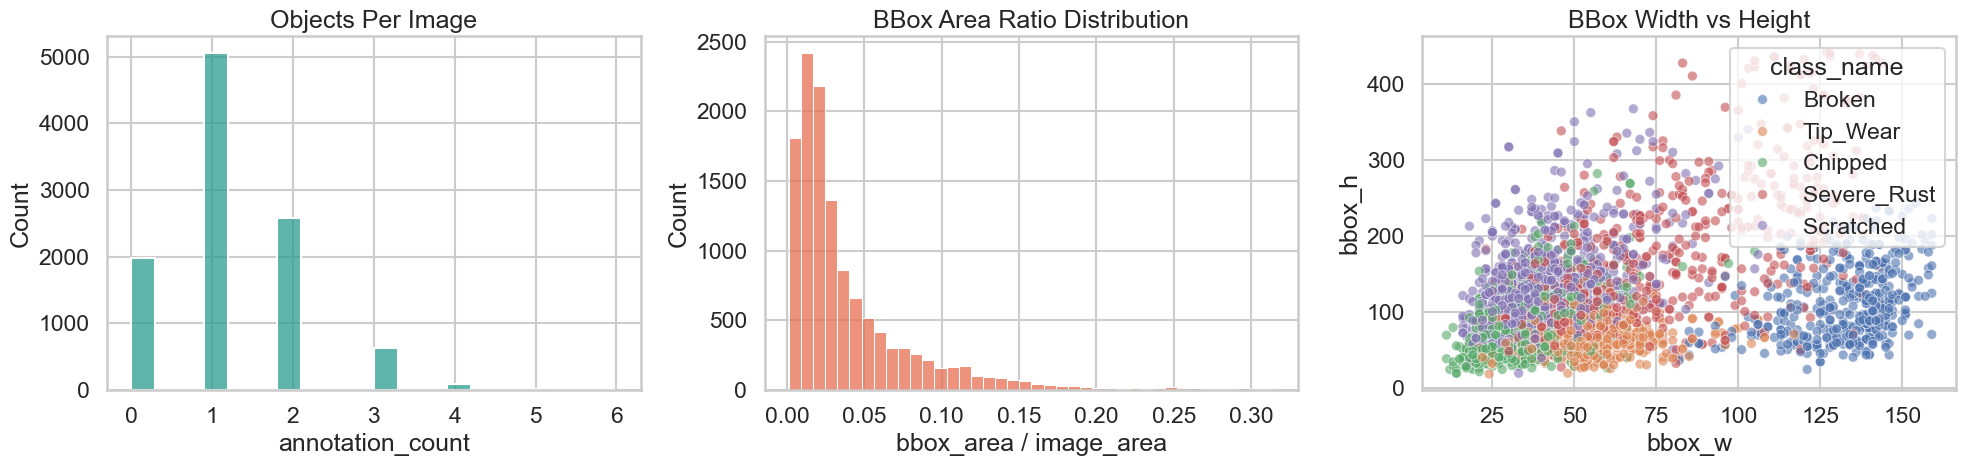

In [7]:
per_image_boxes = (
    image_df.groupby(["split", "image_key"])["annotation_count"].first().reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(data=per_image_boxes, x="annotation_count", bins=20, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Objects Per Image")

sns.histplot(data=bbox_df, x="bbox_area_ratio", bins=40, ax=axes[1], color="#e76f51")
axes[1].set_title("BBox Area Ratio Distribution")
axes[1].set_xlabel("bbox_area / image_area")

sns.scatterplot(
    data=bbox_df.sample(min(len(bbox_df), 3000), random_state=summary["random_seed"]),
    x="bbox_w",
    y="bbox_h",
    hue="class_name",
    alpha=0.6,
    s=50,
    ax=axes[2],
)
axes[2].set_title("BBox Width vs Height")

plt.tight_layout()
save_figure("bbox_statistics", fig)
plt.show()

Saved figure to output/EDA/group_and_source_distribution.png


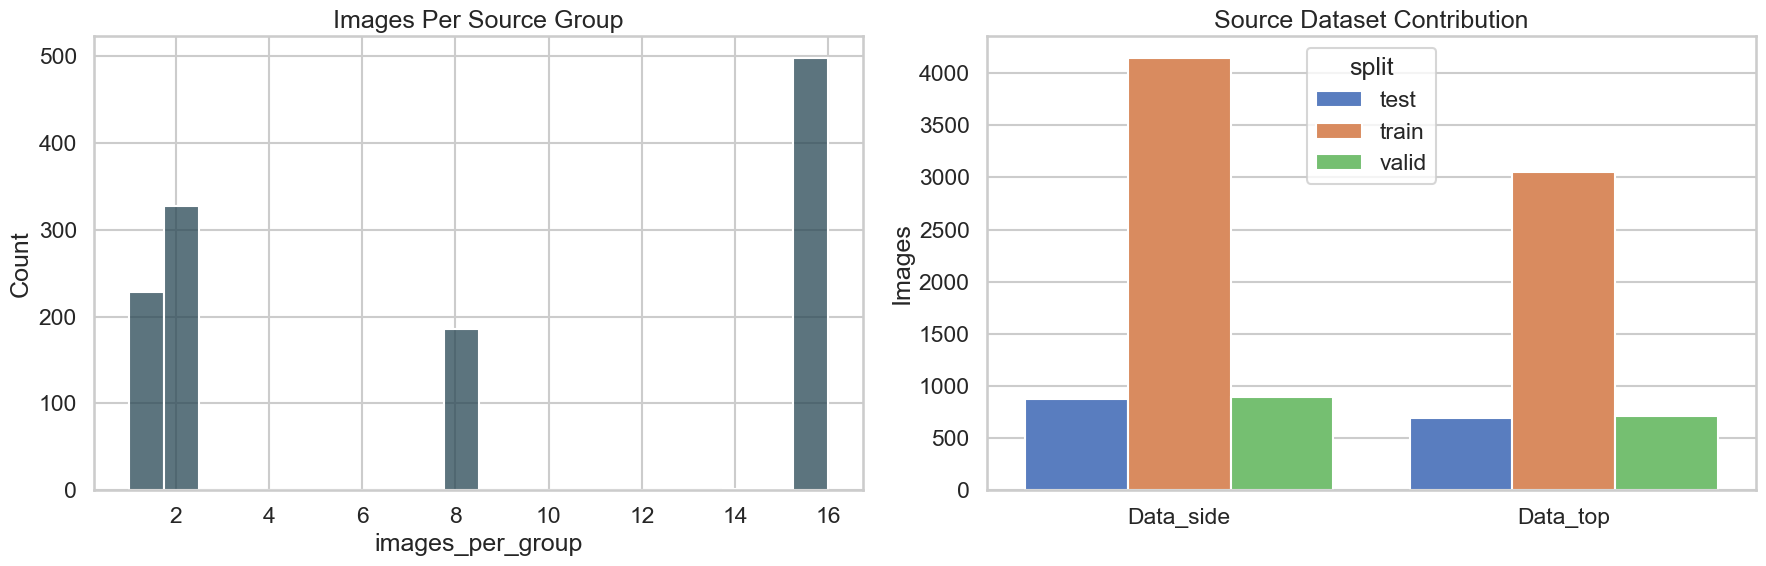

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

group_sizes = image_df.groupby("group_key").size().rename("images_per_group").reset_index()
sns.histplot(data=group_sizes, x="images_per_group", bins=20, ax=axes[0], color="#264653")
axes[0].set_title("Images Per Source Group")

source_mix = image_df.groupby(["dataset", "split"]).size().rename("count").reset_index()
sns.barplot(data=source_mix, x="dataset", y="count", hue="split", ax=axes[1], palette="muted")
axes[1].set_title("Source Dataset Contribution")
axes[1].set_xlabel("")
axes[1].set_ylabel("Images")

plt.tight_layout()
save_figure("group_and_source_distribution", fig)
plt.show()

In [9]:
leakage_count = image_df.groupby("group_key")["split"].nunique().gt(1).sum()
leakage_count

np.int64(0)

Saved figure to output/EDA/class_distribution_by_split.png


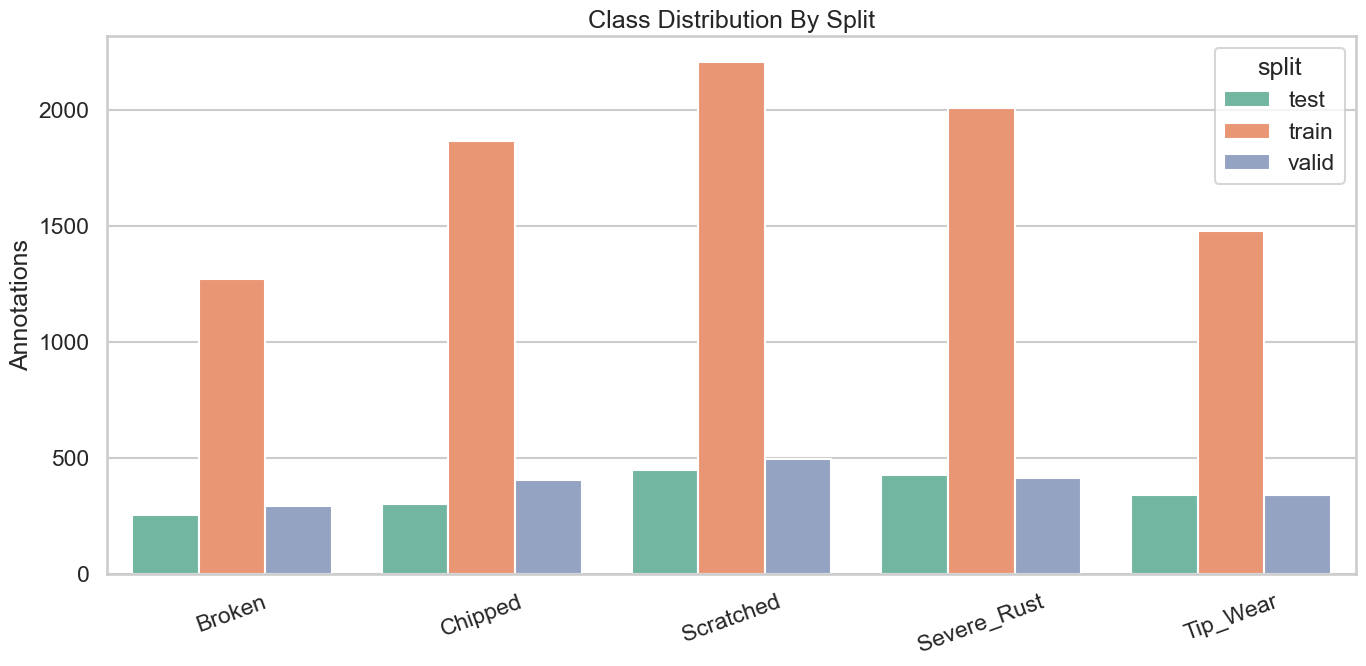

In [10]:
class_by_split = bbox_df.groupby(["split", "class_name"]).size().rename("count").reset_index()
plt.figure(figsize=(14, 7))
sns.barplot(data=class_by_split, x="class_name", y="count", hue="split", palette="Set2")
plt.title("Class Distribution By Split")
plt.xlabel("")
plt.ylabel("Annotations")
plt.xticks(rotation=20)
plt.tight_layout()
save_figure("class_distribution_by_split")
plt.show()

In [11]:
def draw_sample_grid(
    split: str, positive_only: bool = True, sample_size: int = 6, output_name: str = None
) -> None:
    subset = image_df[image_df["split"] == split].copy()
    if positive_only:
        subset = subset[subset["annotation_count"] > 0]

    if subset.empty:
        print(f"No samples available for split={split}, positive_only={positive_only}")
        return

    chosen = subset.sample(min(sample_size, len(subset)), random_state=summary["random_seed"])
    merged = chosen.merge(
        bbox_df,
        on=["split", "group_key", "image_key", "orientation", "field", "dataset"],
        how="left",
    )

    cols = 3
    rows = math.ceil(len(chosen) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.ravel():
        ax.axis("off")

    for ax, (_, image_row) in zip(axes.ravel(), chosen.iterrows()):
        image_path = PROJECT_ROOT / image_row["output_image"]
        image = Image.open(image_path).convert("RGB")
        ax.imshow(image)
        ax.set_title(
            f"{image_row['split']} | {image_row['orientation']} | "
            f"{image_row['field']}\nann={image_row['annotation_count']}"
        )
        ax.axis("off")

        boxes = merged[merged["image_key"] == image_row["image_key"]]
        for _, box in boxes.dropna(subset=["class_name"]).iterrows():
            rect = patches.Rectangle(
                (box["bbox_x"], box["bbox_y"]),
                box["bbox_w"],
                box["bbox_h"],
                linewidth=2,
                edgecolor="lime",
                facecolor="none",
            )
            ax.add_patch(rect)
            ax.text(
                box["bbox_x"],
                max(4, box["bbox_y"] - 4),
                box["class_name"],
                color="black",
                fontsize=10,
                bbox={"facecolor": "yellow", "alpha": 0.7, "pad": 1},
            )

    plt.tight_layout()
    if output_name is not None:
        save_figure(output_name, fig)
    plt.show()

Saved figure to output/EDA/sample_grid_train_positive.png


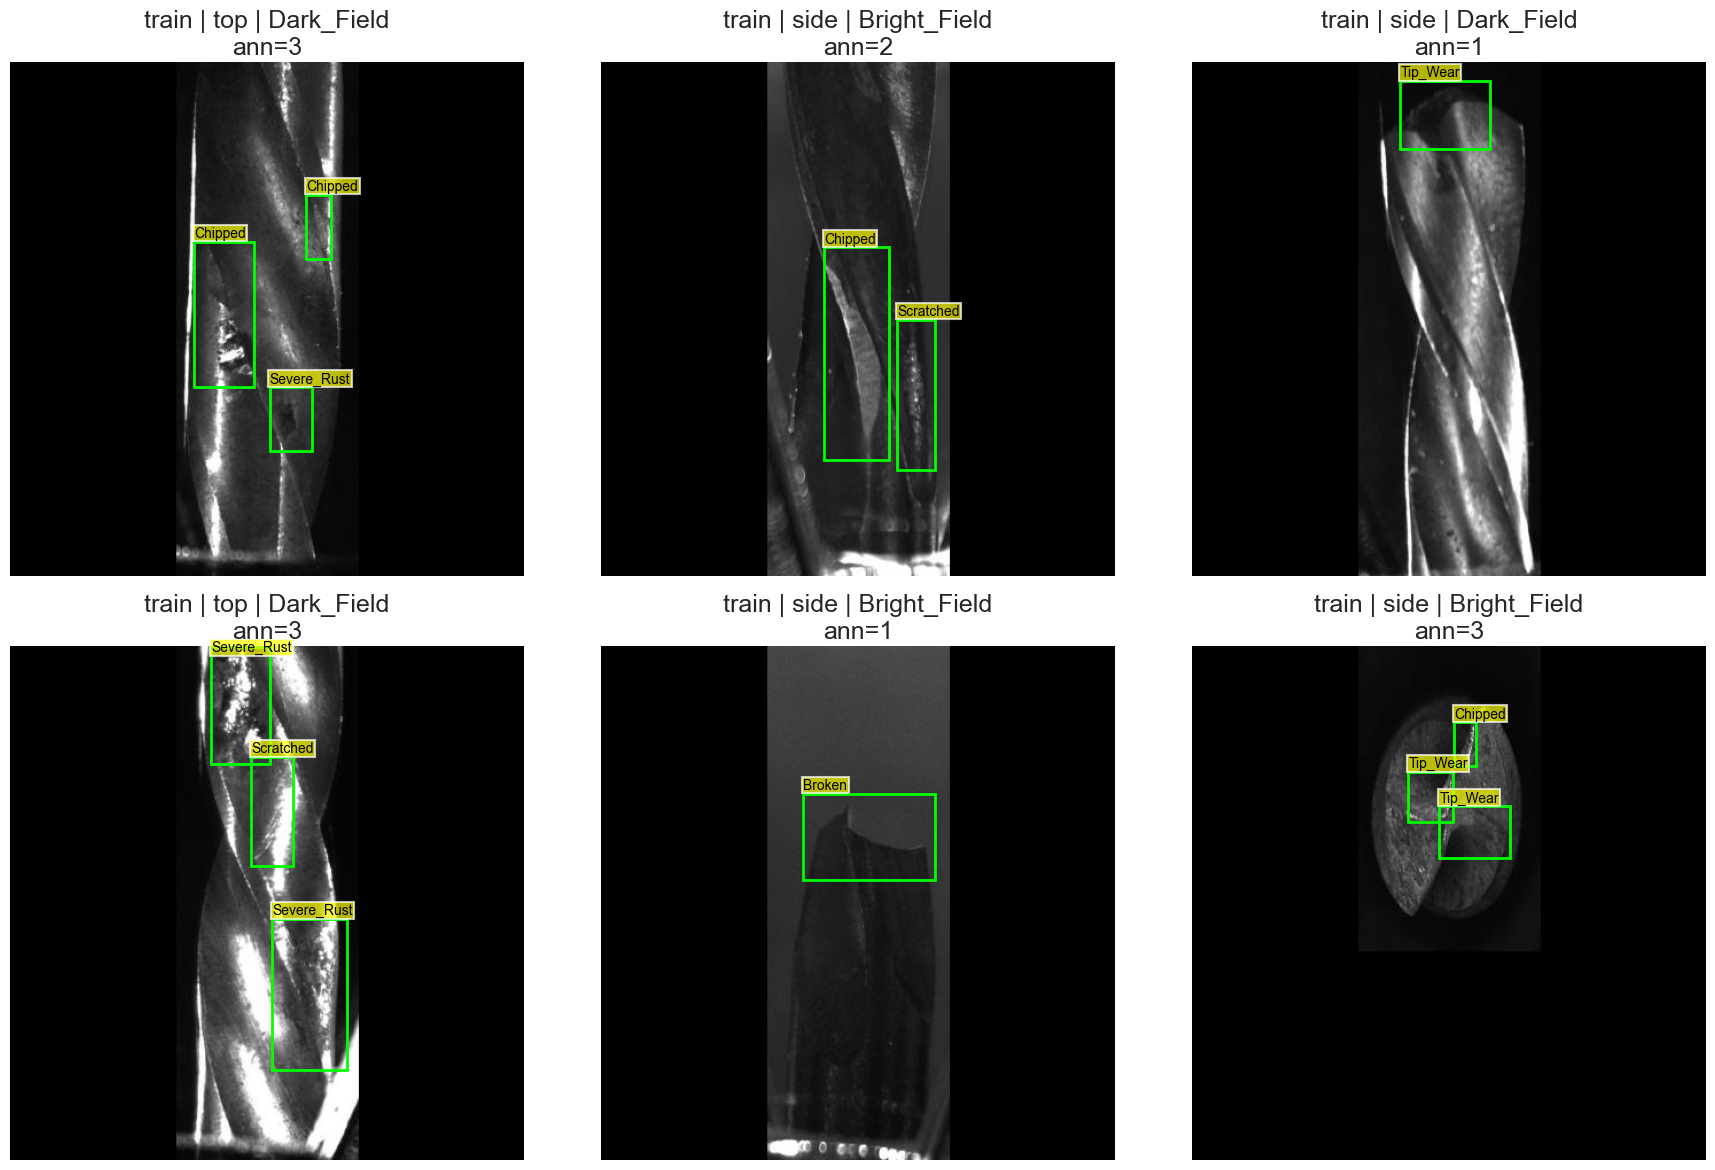

In [12]:
draw_sample_grid(split="train", positive_only=True, sample_size=6, output_name="sample_grid_train_positive")


Saved figure to output/EDA/sample_grid_valid_positive.png


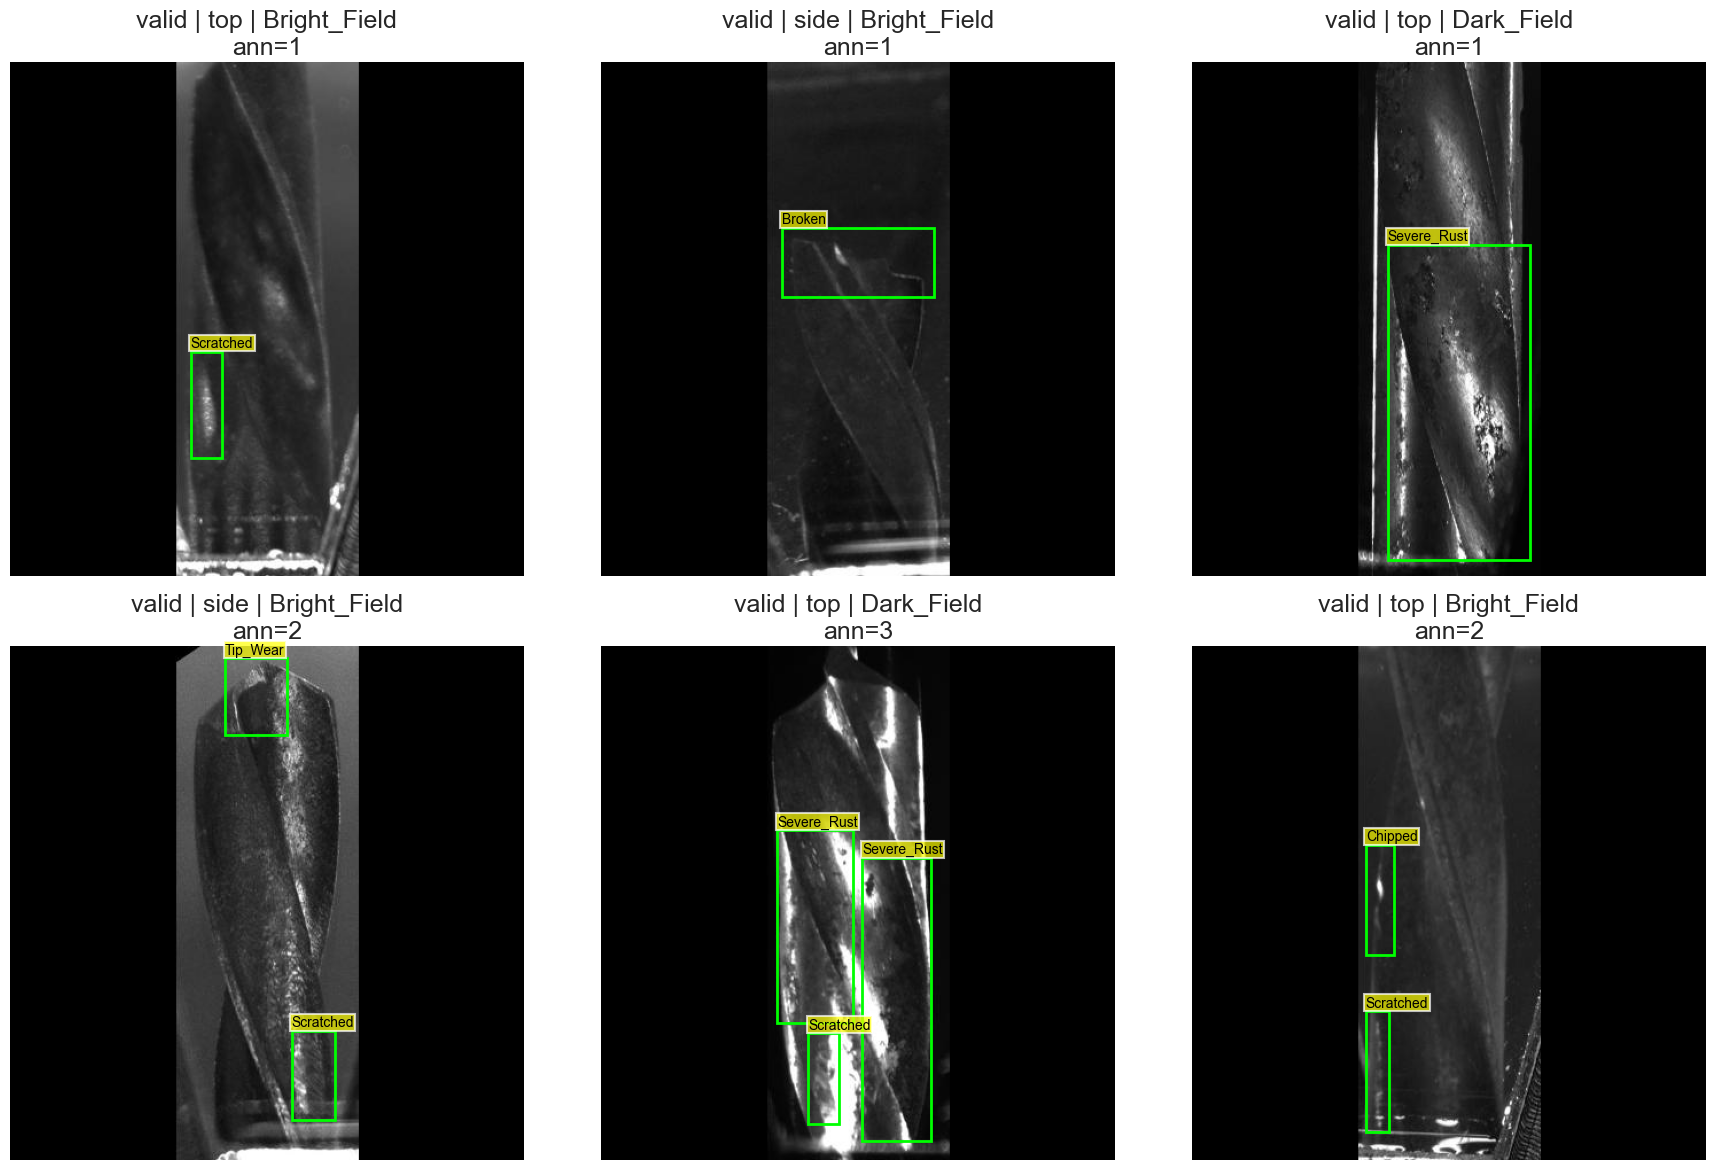

In [13]:
draw_sample_grid(split="valid", positive_only=True, sample_size=6, output_name="sample_grid_valid_positive")


Saved figure to output/EDA/sample_grid_test_mixed.png


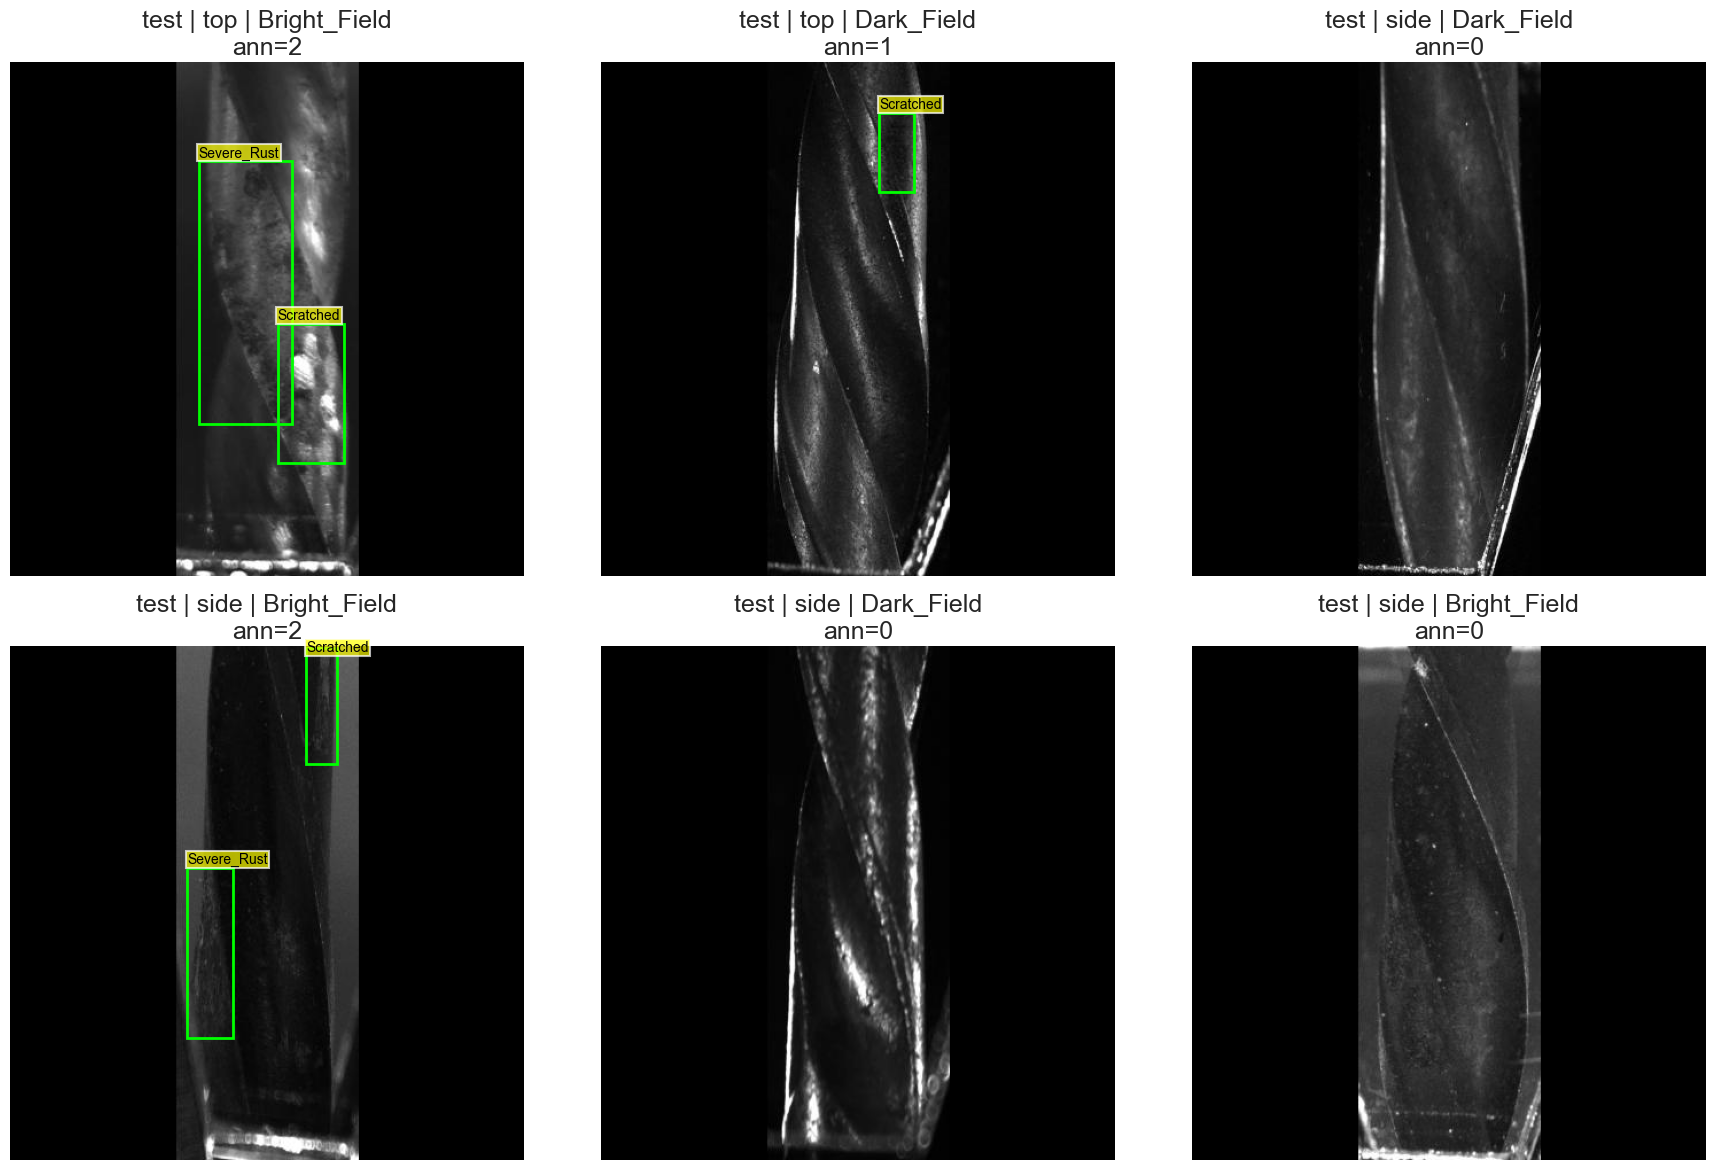

In [14]:
draw_sample_grid(split="test", positive_only=False, sample_size=6, output_name="sample_grid_test_mixed")
